In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')

nltk.download('stopwords')

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

2025-07-10 18:58:37.141936: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752188317.223524   13946 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752188317.246115   13946 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752188317.380040   13946 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752188317.380084   13946 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752188317.380086   13946 computation_placer.cc:177] computation placer alr

Libraries imported successfully!
TensorFlow version: 2.19.0


[nltk_data] Downloading package punkt to /home/paul/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/paul/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/paul/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# List physical devices
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("🚀 GPU(s) detected!")
    for gpu in gpus:
        print(f" - {gpu}")
    print("TensorFlow will use the GPU by default when available.")
else:
    print("⚠️ No GPU detected. Using CPU only.")

🚀 GPU(s) detected!
 - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
TensorFlow will use the GPU by default when available.


In [3]:
# Load the dataset
df = pd.read_csv('/home/paul/Song-Classifier/Data/cleaned_rock_country_hiphop_rb.csv')

# Display basic info about the dataset
print("Dataset shape:", df.shape)
print("\nDataset info:")
print(df.info())
print("\nGenre distribution:")
print(df['type'].value_counts())
print("\nFirst few rows:")
print(df.head())

Dataset shape: (3764, 5)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3764 entries, 0 to 3763
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   song                    3764 non-null   object
 1   artist                  3764 non-null   object
 2   type                    3764 non-null   object
 3   contains_special_chars  3764 non-null   bool  
 4   lyrics                  3764 non-null   object
dtypes: bool(1), object(4)
memory usage: 121.4+ KB
None

Genre distribution:
type
country          969
rock             950
R&B              938
rap & hip hop    907
Name: count, dtype: int64

First few rows:
                        song        artist  type  contains_special_chars  \
0         Stairway to Heaven  Led Zeppelin  rock                   False   
1       Like A Rolling Stone    Dylan, Bob  rock                   False   
2  Another Brick In The Wall    Pink Floyd  rock     

In [4]:
# Text preprocessing function
def preprocess_text(text):
    """
    Preprocess text data for LSTM model
    """
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]
    
    return ' '.join(tokens)

# Apply preprocessing
print("Preprocessing lyrics...")
df['processed_lyrics'] = df['lyrics'].apply(preprocess_text)

# Remove rows with empty processed lyrics
df = df[df['processed_lyrics'].str.len() > 0]
print(f"Dataset shape after preprocessing: {df.shape}")

Preprocessing lyrics...
Dataset shape after preprocessing: (3763, 6)


In [5]:
# Prepare features and labels
X = df['processed_lyrics'].values
y = df['type'].values

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Get number of classes
num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")
print(f"Classes: {label_encoder.classes_}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Number of classes: 4
Classes: ['R&B' 'country' 'rap & hip hop' 'rock']
Training set size: 3010
Test set size: 753


In [6]:
# Tokenization parameters
MAX_VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 200

# Create and fit tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

print(f"Vocabulary size: {len(tokenizer.word_index) + 1}")
print(f"Training sequences shape: {X_train_padded.shape}")
print(f"Test sequences shape: {X_test_padded.shape}")

Vocabulary size: 47346
Training sequences shape: (3010, 200)
Test sequences shape: (753, 200)


In [7]:
print(f"Test sequences shape: {X_test_padded.shape}")

# --- NEW CELL ---
# Load GloVe embeddings and create embedding matrix
print("Loading GloVe embeddings...")
# !!! IMPORTANT: Update this path to where you saved the GloVe file !!!
glove_file = '/home/paul/Song-Classifier/glove.6B.100d.txt' 
embeddings_index = {}
try:
    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
except FileNotFoundError:
    print(f"Error: GloVe file not found at {glove_file}")
    print("Please download glove.6B.100d.txt and update the path.")

print(f"Found {len(embeddings_index)} word vectors in GloVe file.")

# Create a weight matrix for words in training docs
embedding_dim = 100  # Must match the GloVe file dimension (e.g., 100d)
embedding_matrix = np.zeros((MAX_VOCAB_SIZE, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < MAX_VOCAB_SIZE:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            # Words not found in embedding index will be all-zeros.
            embedding_matrix[i] = embedding_vector

print("Embedding matrix created.")

Test sequences shape: (753, 200)
Loading GloVe embeddings...
Found 400000 word vectors in GloVe file.
Embedding matrix created.


In [8]:
# Build the LSTM model
def create_lstm_model(embedding_matrix):
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB_SIZE, 
                  output_dim=100,  # Must match GloVe dimension
                  weights=[embedding_matrix], 
                  input_length=MAX_SEQUENCE_LENGTH,
                  # Let's fine-tune the embedding layer
                  trainable=True), 
        
        # Add recurrent_dropout for better regularization
        Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)),
        
        # Add L2 regularization to the Dense layer
        Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dropout(0.5),
        
        Dense(num_classes, activation='softmax')
    ])
        
    return model

# Create the model
model = create_lstm_model(embedding_matrix)

# Compile the model with a lower learning rate for fine-tuning
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# Display model summary
print("Model Architecture:")
model.summary()

I0000 00:00:1752188330.068125   13946 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 1,000,000 (3.81 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.0001,
    verbose=1
)

# Train the model
print("Training the model...")
history = model.fit(
    X_train_padded, y_train,
    validation_data=(X_test_padded, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("Training completed!")

Training the model...
Epoch 1/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 244s 2s/step - accuracy: 0.3501 - loss: 1.3808 - val_accuracy: 0.4489 - val_loss: 1.2031 - learning_rate: 5.0000e-04
Epoch 2/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 235s 2s/step - accuracy: 0.4556 - loss: 1.2166 - val_accuracy: 0.4622 - val_loss: 1.1661 - learning_rate: 5.0000e-04
Epoch 3/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 258s 2s/step - accuracy: 0.5044 - loss: 1.1525 - val_accuracy: 0.5007 - val_loss: 1.1172 - learning_rate: 5.0000e-04
Epoch 4/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 229s 2s/step - accuracy: 0.5261 - loss: 1.1269 - val_accuracy: 0.5272 - val_loss: 1.0836 - learning_rate: 5.0000e-04
Epoch 5/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.5599 - loss: 1.0676 - val_accuracy: 0.5299 - val_loss: 1.0793 - learning_rate: 5.0000e-04
Epoch 6/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.5737 - loss: 1.0178 - val_accuracy: 0.5445 - val_loss: 1.0584 - learning_rate: 5.0000e-04
Epoch 7/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 229s 2s/st

Test Accuracy: 0.6056
Test Loss: 0.9865
24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 638ms/step

Classification Report:
               precision    recall  f1-score   support

          R&B       0.56      0.63      0.59       188
      country       0.59      0.57      0.58       194
rap & hip hop       0.81      0.87      0.84       181
         rock       0.43      0.37      0.40       190

     accuracy                           0.61       753
    macro avg       0.60      0.61      0.60       753
 weighted avg       0.60      0.61      0.60       753



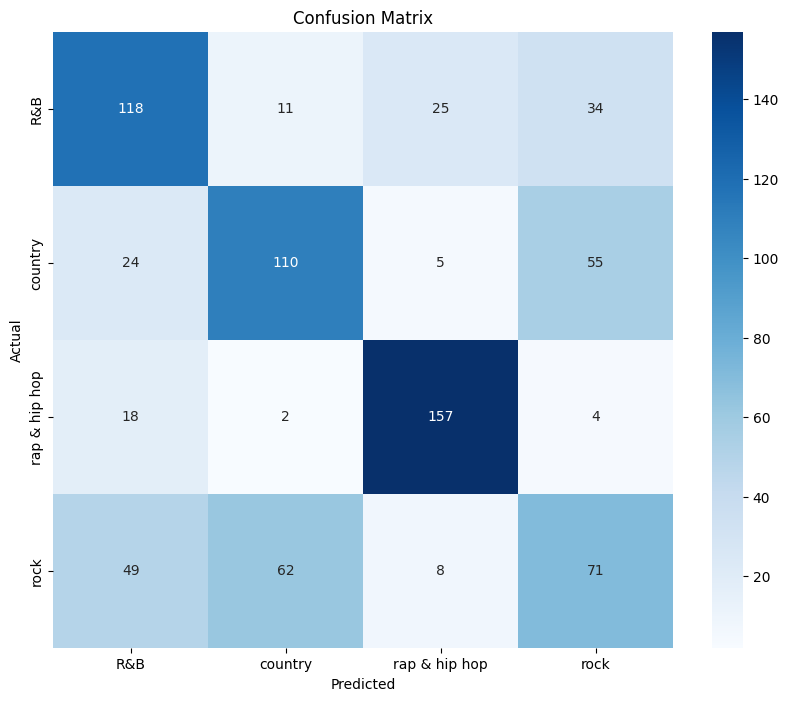

In [10]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test_padded, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Make predictions
y_pred = model.predict(X_test_padded)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, 
                          target_names=label_encoder.classes_))

# Confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

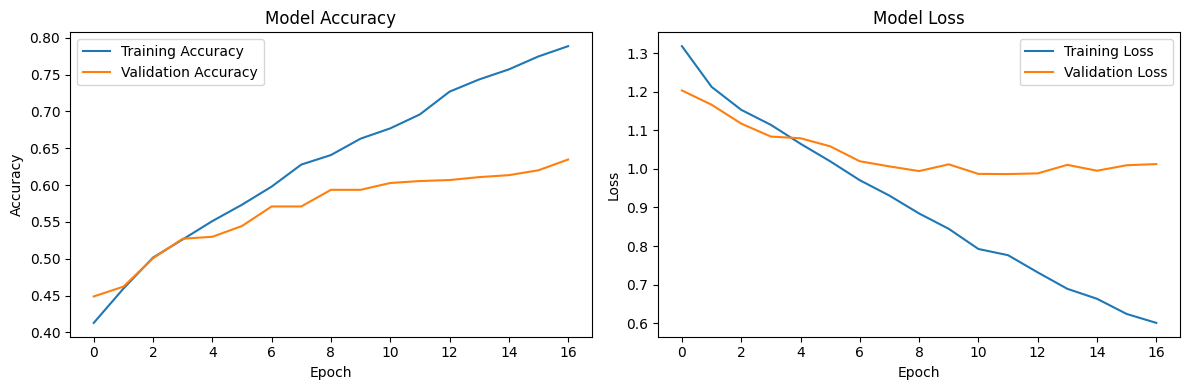

In [11]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()